<a href="https://colab.research.google.com/github/jay01996/Program-1-weather-probability-and-conditional-probability-data-analysis/blob/main/weather_probability_conditional_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("weather_probability_dataset.csv")
df

,Date,Temperature_C,Humidity_%,Pressure_hPa,WindSpeed_kmh,CloudCover_%,Visibility_km,WindDirection,Rainfall_mm,WeatherCondition,RainToday,RainTomorrow,HighHumidity,HighWind,HighCloudCover,LowPressure,TemperatureGroup
0,2025-01-01,30.0,47.8,1018.5,8.6,90,9.0,E,1.3,Cloudy,No,No,No,No,Yes,No,Moderate
1,2025-01-02,26.2,82.7,1025.4,5.2,78,10.5,W,12.1,Light Rain,Yes,Yes,Yes,No,Yes,No,Moderate
2,2025-01-03,30.9,98.0,1002.2,8.2,56,2.0,S,6.3,Light Rain,Yes,Yes,Yes,No,No,Yes,High
3,2025-01-04,36.1,84.5,1015.9,24.4,39,9.1,N,19.4,Light Rain,Yes,Yes,Yes,No,No,No,High
4,2025-01-05,25.6,43.7,1007.4,8.4,72,11.7,N,11.0,Light Rain,Yes,No,No,No,Yes,Yes,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,2025-09-03,25.0,76.6,1006.9,13.8,24,14.0,NE,0.2,Sunny,No,No,Yes,No,No,Yes,Moderate
246,2025-09-04,24.2,51.4,1013.3,30.4,56,14.2,N,1.4,Partly Cloudy,No,No,No,Yes,No,No,Moderate
247,2025-09-05,23.1,65.0,1006.7,21.1,36,11.6,E,0.3,Partly Cloudy,No,No,No,No,No,Yes,Moderate
248,2025-09-06,37.6,54.0,1007.7,11.4,61,11.1,SW,6.6,Light Rain,Yes,No,No,No,No,Yes,High


In [ ]:
df.head()

,Date,Temperature_C,Humidity_%,Pressure_hPa,WindSpeed_kmh,CloudCover_%,Visibility_km,WindDirection,Rainfall_mm,WeatherCondition,RainToday,RainTomorrow,HighHumidity,HighWind,HighCloudCover,LowPressure,TemperatureGroup
0,2025-01-01,30.0,47.8,1018.5,8.6,90,9.0,E,1.3,Cloudy,No,No,No,No,Yes,No,Moderate
1,2025-01-02,26.2,82.7,1025.4,5.2,78,10.5,W,12.1,Light Rain,Yes,Yes,Yes,No,Yes,No,Moderate
2,2025-01-03,30.9,98.0,1002.2,8.2,56,2.0,S,6.3,Light Rain,Yes,Yes,Yes,No,No,Yes,High
3,2025-01-04,36.1,84.5,1015.9,24.4,39,9.1,N,19.4,Light Rain,Yes,Yes,Yes,No,No,No,High
4,2025-01-05,25.6,43.7,1007.4,8.4,72,11.7,N,11.0,Light Rain,Yes,No,No,No,Yes,Yes,Moderate


In [ ]:
df.shape

(250, 17)

In [ ]:
df.columns.to_list()

['Date',
 'Temperature_C',
 'Humidity_%',
 'Pressure_hPa',
 'WindSpeed_kmh',
 'CloudCover_%',
 'Visibility_km',
 'WindDirection',
 'Rainfall_mm',
 'WeatherCondition',
 'RainToday',
 'RainTomorrow',
 'HighHumidity',
 'HighWind',
 'HighCloudCover',
 'LowPressure',
 'TemperatureGroup']

In [ ]:
df['RainTomorrow'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
# Step 7: Count rainy and non-rainy days
df['RainTomorrow'].value_counts()

,count
RainTomorrow,
Yes,135
No,115


Step 7 — Calculate basic probability

Our first question is:

**What is the probability that it will rain tomorrow?**

**Mathematically:**

P(RainTomorrow)=
Total number of days/
Number of rainy days
	​


In [ ]:
rainy_days  = (df['RainTomorrow'] == 'Yes').sum()
total_days = len(df)
probability = rainy_days / total_days
print("Rainy Days", rainy_days)
print("Total Days", total_days)
print("Probability of Rain", int(probability*100), '%')

Rainy Days 135
Total Days 250
Probability of Rain 54 %


Step 9 — Now calculate Conditional Probability

Suppose the weather department asks:

**If it is raining today, what is the probability that it will rain tomorrow?**

This is: P(RainTomorrow / RainToday)

Read it as: *Probability of rain tomorrow given that it is raining today.*

In [ ]:
# Step 10 — Filter the dataset
rain_today_df = df[df['RainToday'] == 'Yes']
# step 11, find total days
len(rain_today_df)

116

In [ ]:
# Step 12 Count how many of those had rain tomorrow
rain_tomorrow_after_rain_today  = (rain_today_df['RainTomorrow'] == 'Yes').sum()
rain_tomorrow_after_rain_today

np.int64(88)

In [ ]:
# Step 13 — Calculate conditional probability
conditional_probability = rain_tomorrow_after_rain_today / len(rain_today_df) * 100
print("P(RainTomorrow | RainToday) =", round(conditional_probability, 2), '%')

P(RainTomorrow | RainToday) = 75.86 %


In [ ]:
# Step 14 — Calculate it using Pandas .mean()
conditional_probability1 = (df[df['RainToday'] == 'Yes']['RainTomorrow'] == 'Yes').mean() * 100
print(round(conditional_probability1, 2), '%')

75.86 %


Step 15 — Try another condition: High Humidity

Now answer:

**What is the probability of rain tomorrow when humidity is high?**

We already created a column: HighHumidity

In [ ]:
# step 15
# Check highHumidity Column
df['HighHumidity'].value_counts()

,count
HighHumidity,
No,143
Yes,107


In [ ]:
probability_high_humidity = (df[df['HighHumidity'] == 'Yes']['RainTomorrow'] == 'Yes').mean() * 100
print('probability_high_humidity is',round(probability_high_humidity, 2), '%')

probability_high_humidity is 71.03 %


**Step 16 — Try Low Pressure**

Question:

**What is the probability of rain tomorrow when atmospheric pressure is low?**

In [ ]:
# Step 16 - Low Pressure
df['LowPressure'].value_counts()


,count
LowPressure,
No,179
Yes,71


In [ ]:
probability_low_pressure = (df[df['LowPressure'] == 'Yes'] ['RainTomorrow'] == 'Yes').mean()
print(f'probability_low_pressure is {round(probability_low_pressure * 100,2)}%')
# probability_low_pressure

probability_low_pressure is 67.61%


**Step 17 — Try High Cloud Cover**

Question:

**What is the probability of rain tomorrow when cloud cover is high?**

In [ ]:
df['HighCloudCover'].value_counts()

,count
HighCloudCover,
No,172
Yes,78


In [ ]:
probability_high_cloud = (df[df['HighCloudCover'] == 'Yes'] ['RainTomorrow'] == 'Yes').mean()
print(f'probability_high_cloud {round(probability_high_cloud*100, 2)} %')

probability_high_cloud 62.82 %


**Step 18 — Compare all conditions**

In [ ]:
results = {
    'Condition': [
        'Overall',
        'Rain Today',
        'High Humidity',
        'Low Pressure',
        'High Cloud Cover'
    ],

    'Probability': [
        (df['RainTomorrow'] == 'Yes').mean(),
        (df[df['RainToday'] == 'Yes']['RainTomorrow'] == 'Yes').mean(),
        (df[df['HighHumidity'] == 'Yes']['RainTomorrow'] == 'Yes').mean(),
        (df[df['LowPressure'] == 'Yes']['RainTomorrow'] == 'Yes').mean(),
        (df[df['HighCloudCover'] == 'Yes']['RainTomorrow'] == 'Yes').mean()
    ]
}

results_df = pd.DataFrame(results)
results_df

,Condition,Probability
0,Overall,0.540000
1,Rain Today,0.758621
2,High Humidity,0.710280
3,Low Pressure,0.676056
4,High Cloud Cover,0.628205


In [ ]:
# Convert to percentage by adding new column
results_df['Probability (%)'] = (
    results_df['Probability'] * 100
)
results_df

,Condition,Probability,Probability (%)
0,Overall,0.540000,54.000000
1,Rain Today,0.758621,75.862069
2,High Humidity,0.710280,71.028037
3,Low Pressure,0.676056,67.605634
4,High Cloud Cover,0.628205,62.820513


**Step 19 — Visualize the probabilities**

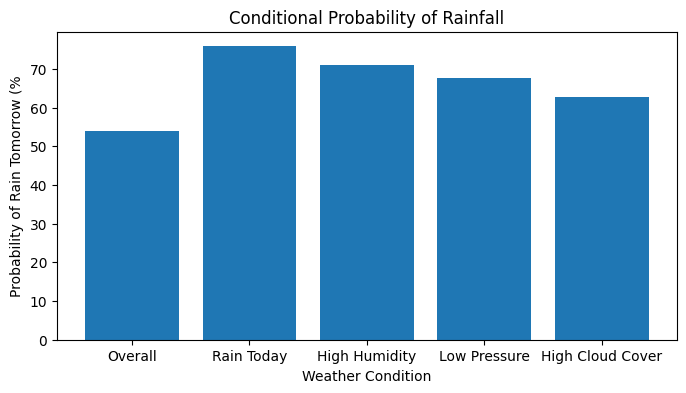

In [ ]:
# Step 19, Import matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize = (8,4))
plt.bar(results_df['Condition'], results_df['Probability (%)'])
plt.xlabel("Weather Condition")
plt.ylabel("Probability of Rain Tomorrow (%")
plt.title('Conditional Probability of Rainfall')
plt.show()